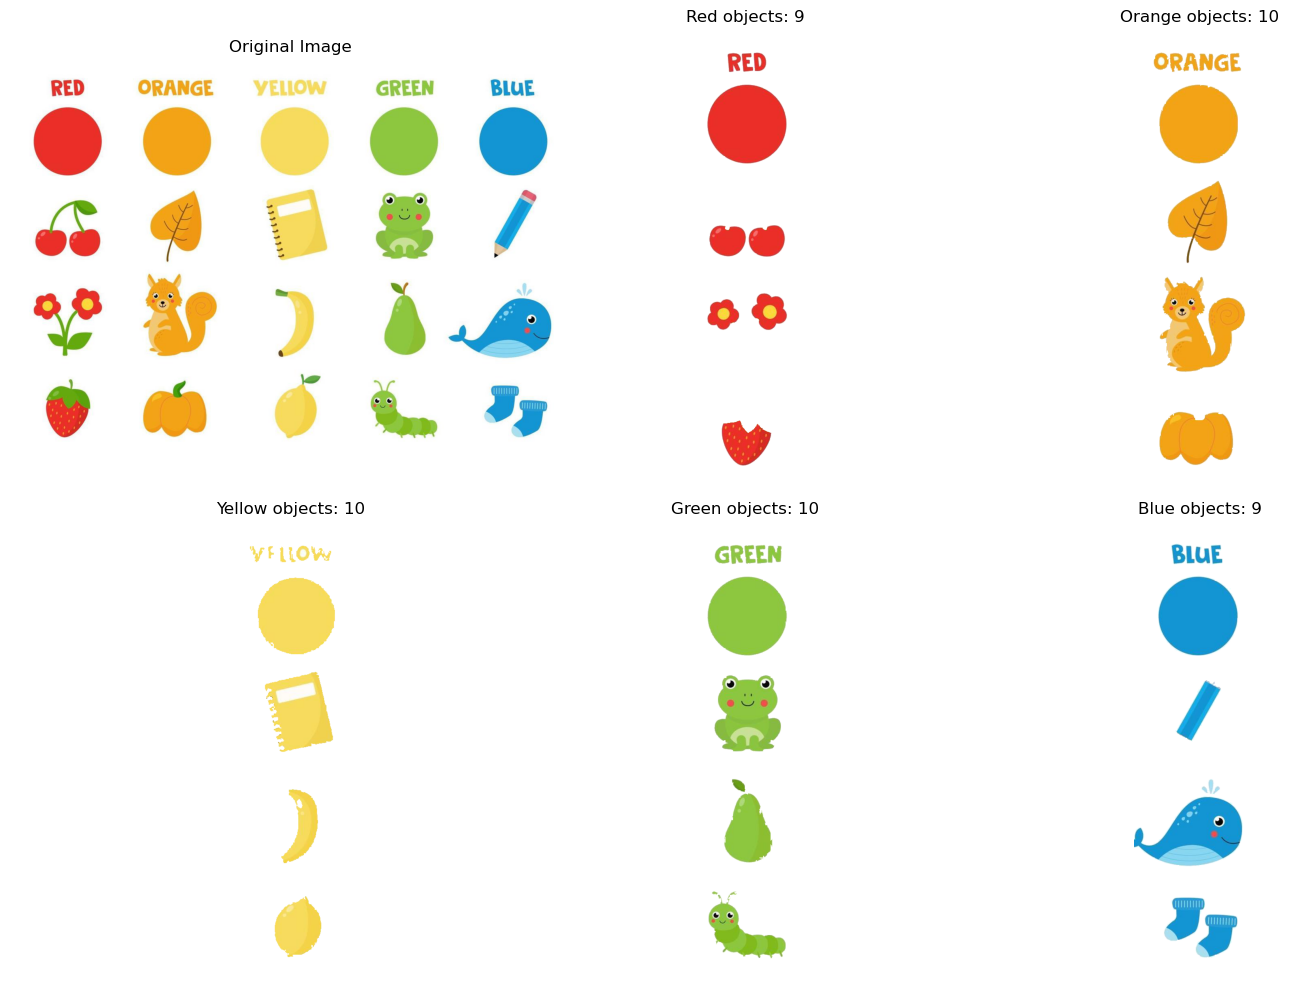

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

rangos_hsv = {
    'Red': [
        ([0, 50, 50], [10, 255, 255]),
        ([160, 50, 50], [179, 255, 255])
    ],
    'Orange': [
        ([11, 50, 50], [22, 255, 255])
    ],
  
    'Yellow': [
        ([24, 140, 120], [35, 255, 255])
    ],

    'Green': [
        ([40, 51, 50], [85, 255, 255])
    ],
  
    'Blue': [
        ([85, 20, 20], [140, 255, 255])
    ]
}

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
axs[0].imshow(img_rgb)
axs[0].set_title('Original Image')
axs[0].axis('off')

ancho_col = img.shape[1] // 5

for i, (color, rangos) in enumerate(rangos_hsv.items()):
    x_ini = i * ancho_col
    x_fin = (i + 1) * ancho_col if i < 4 else img.shape[1]

    col_rgb = img_rgb[:, x_ini:x_fin]
    col_hsv = img_hsv[:, x_ini:x_fin]

    mask = np.zeros(col_hsv.shape[:2], dtype="uint8")
    for (lower, upper) in rangos:
        lower = np.array(lower, dtype=np.uint8)
        upper = np.array(upper, dtype=np.uint8)
        mask |= cv2.inRange(col_hsv, lower, upper)

    contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # AJUSTE DE ÁREA PARA LEER MÁS: 
    if color == 'Yellow':
        area_min = 80 # Exigente para limpiar el polvillo amarillo
    elif color in ['Green', 'Blue']:
        area_min = 0  # <--- Límite CERO. Atrapa absolutamente cualquier píxel válido que detecte.
    else:
        area_min = 5  # Estándar para Rojo y Naranja

    validos = [c for c in contornos if cv2.contourArea(c) > area_min]

    mask_limpia = np.zeros_like(mask)
    cv2.drawContours(mask_limpia, validos, -1, 255, -1)
    res = np.where(mask_limpia[:, :, None] == 255, col_rgb, 255)

    axs[i+1].imshow(res)
    axs[i+1].set_title(f"{color} objects: {len(validos)}")
    axs[i+1].axis('off')

plt.tight_layout()
plt.show()